<a href="https://colab.research.google.com/github/HanaaMaswada/Zillow-Home-Value-Project/blob/main/Zillow_Home_Value_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

path = '/content/drive/MyDrive/axsos ass/zillow_home_values-zipcode.csv'

df = pd.read_csv(path)
print(df.shape)
df.head()

(27442, 284)


,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,31012000,...,28022022,31032022,30042022,31052022,30062022,31072022,31082022,30092022,31102022,30112022
0,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,107261.0,...,261945.0,267644.0,273946.0,280066.0,285121.0,288532.0,290458.0,291103.0,292081.0,292948.0
1,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,222569.0,...,453150.0,464727.0,478369.0,489712.0,497173.0,499429.0,497572.0,498113.0,500187.0,503109.0
2,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,90009.0,...,177319.0,179463.0,182812.0,186403.0,189836.0,192064.0,193760.0,195140.0,196787.0,198137.0
3,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,188096.0,...,570211.0,572145.0,573662.0,576469.0,578706.0,580834.0,581779.0,584566.0,588188.0,590722.0
4,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,275983.0,...,752025.0,757734.0,760336.0,766163.0,771443.0,776607.0,779281.0,782367.0,788211.0,793924.0


- Date column named **"Date"**
- Value column named **"Home Value"**

In [3]:
id_cols = ['RegionID', 'SizeRank', 'RegionName', 'RegionType',
           'StateName', 'State', 'City', 'Metro', 'CountyName']

df_long = df.melt(id_vars=id_cols, var_name='Date', value_name='Home Value')
df_long.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Date,Home Value
0,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,31012000,107261.0
1,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,31012000,222569.0
2,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,31012000,90009.0
3,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,31012000,188096.0
4,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,31012000,275983.0


2) Convert "Date" to datetime and set it as the index

In [4]:
df_long['Date'] = pd.to_datetime(df_long['Date'], format='%d%m%Y')
df_long = df_long.set_index('Date').sort_index()
df_long.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7546550 entries, 2000-01-31 to 2022-11-30
Data columns (total 10 columns):
 #   Column      Dtype  
---  ------      -----  
 0   RegionID    int64  
 1   SizeRank    int64  
 2   RegionName  int64  
 3   RegionType  object 
 4   StateName   object 
 5   State       object 
 6   City        object 
 7   Metro       object 
 8   CountyName  object 
 9   Home Value  float64
dtypes: float64(1), int64(3), object(6)
memory usage: 633.3+ MB


3) Prepare a filtered copy for Tableau

In [5]:
states = ['CA', 'WA', 'OR', 'AZ', 'NV']

df_tableau = df_long[df_long['State'].isin(states)].copy()
df_tableau = df_tableau[(df_tableau.index.year >= 2010) & (df_tableau.index.year <= 2020)]

print(df_tableau['State'].unique())
print(df_tableau.index.min(), '->', df_tableau.index.max())
print(df_tableau.shape)
df_tableau.head()

['CA' 'WA' 'AZ' 'NV' 'OR']
2010-01-31 00:00:00 -> 2020-12-31 00:00:00
(386892, 10)


,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Home Value
Date,,,,,,,,,,
2010-01-31,95992,5,90011,zip,CA,CA,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,209250.0
2010-01-31,96361,8,91331,zip,CA,CA,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,257372.0
2010-01-31,96193,9,90650,zip,CA,CA,Norwalk,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,296430.0
2010-01-31,96083,12,90201,zip,CA,CA,Bell,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,271829.0
2010-01-31,96816,13,92335,zip,CA,CA,Fontana,"Riverside-San Bernardino-Ontario, CA",San Bernardino County,156704.0


4) Save the processed data as `Data/data-for-tableau.csv`

In [6]:
import os

out_dir = '/content/drive/MyDrive/Data'
os.makedirs(out_dir, exist_ok=True)

df_tableau.to_csv(f'{out_dir}/data-for-tableau.csv')
print('Saved to:', f'{out_dir}/data-for-tableau.csv')

Saved to: /content/drive/MyDrive/Data/data-for-tableau.csv


 5) Resample to yearly frequency (calendar year start), grouped by state, using the mean


In [7]:
yearly = (df_tableau
          .groupby('State')['Home Value']
          .resample('YS')      # YS = calendar Year Start
          .mean()
          .unstack(level='State'))
yearly

State,AZ,CA,NV,OR,WA
Date,,,,,
2010-01-01,169930.889076,415491.808100,189285.319787,224035.019849,250932.487018
2011-01-01,152272.467002,388468.031550,168931.537037,205273.042225,230557.026098
2012-01-01,159902.057789,388593.634299,165003.293888,201899.022119,225432.142832
2013-01-01,183657.225403,454509.845597,199847.532946,216964.502931,240848.444598
2014-01-01,198551.492521,505808.423831,228975.139535,233022.531108,256869.916239
2015-01-01,206834.173937,535297.119658,247372.119614,249633.916898,275704.942220
2016-01-01,217452.799614,569319.272450,265123.976834,272424.454568,302116.532078
2017-01-01,229066.028099,601938.428066,284543.217949,294524.759060,334494.267926
2018-01-01,244689.172792,646936.553061,319753.462629,311491.056020,367370.462736


6) Line plot — each state as a separate line

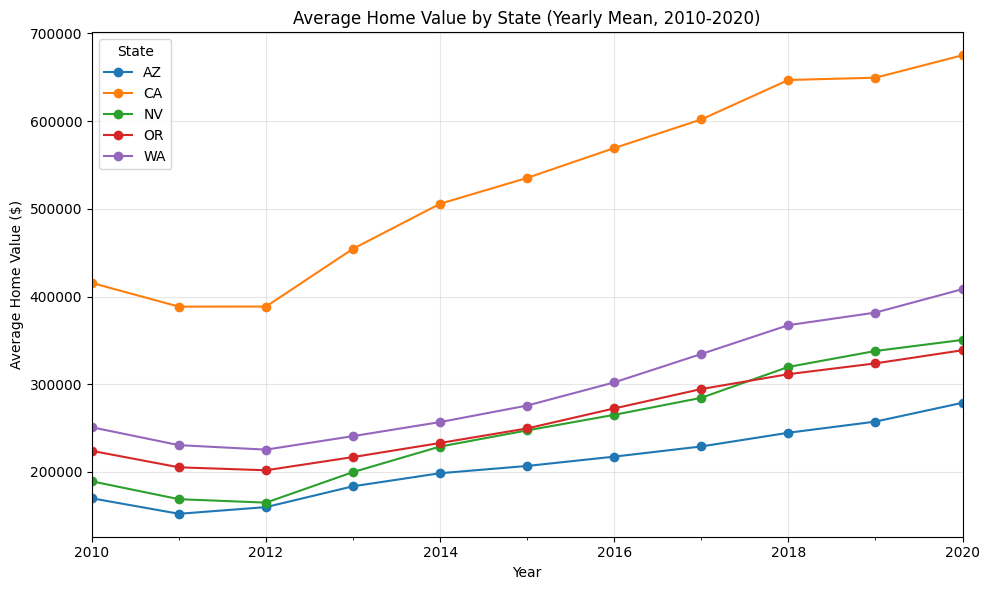

In [8]:
ax = yearly.plot(figsize=(10, 6), marker='o')
ax.set_title('Average Home Value by State (Yearly Mean, 2010-2020)')
ax.set_xlabel('Year')
ax.set_ylabel('Average Home Value ($)')
ax.legend(title='State')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Part 2

In [9]:
try:
    import pmdarima
    print('pmdarima OK:', pmdarima.__version__)
except Exception:
    print('Installing pmdarima (with compatible numpy)...')
    !pip install "numpy<2" pmdarima -q
    print('\n>>> Now go to: Runtime -> Restart session, then run the notebook from the top. <<<')

Installing pmdarima (with compatible numpy)...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 26.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
!find /content/drive/MyDrive -maxdepth 3 -iname "*zillow*"

/content/drive/MyDrive/axsos ass/zillow_home_values-zipcode.csv


In [14]:
import warnings
warnings.filterwarnings('ignore')   # exam note: warnings during model fitting are okay

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TODO: adjust this path to where the file is saved in your Drive
path = '/content/drive/MyDrive/axsos ass/zillow_home_values-zipcode.csv'
df = pd.read_csv(path)

id_cols = ['RegionID', 'SizeRank', 'RegionName', 'RegionType',
           'StateName', 'State', 'City', 'Metro', 'CountyName']

df_or = df[df['State'] == 'OR']
print('Oregon zipcodes:', df_or['RegionName'].nunique())

df_long = df_or.melt(id_vars=id_cols, var_name='Date', value_name='Home Value')
df_long['Date'] = pd.to_datetime(df_long['Date'], format='%d%m%Y')   # dates are DDMMYYYY
df_long = df_long.set_index('Date').sort_index()
df_long.head()

Oregon zipcodes: 365


,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Home Value
Date,,,,,,,,,,
2000-01-31,99142,262,97229,zip,OR,OR,Portland,"Portland-Vancouver-Hillsboro, OR-WA",Washington County,260209.0
2000-01-31,99178,489,97301,zip,OR,OR,Salem,"Salem, OR",Marion County,109851.0
2000-01-31,99048,528,97045,zip,OR,OR,Oregon City,"Portland-Vancouver-Hillsboro, OR-WA",Clackamas County,204570.0
2000-01-31,99093,549,97124,zip,OR,OR,Hillsboro,"Portland-Vancouver-Hillsboro, OR-WA",Washington County,181574.0
2000-01-31,99252,656,97402,zip,OR,OR,Eugene,"Eugene-Springfield, OR",Lane County,136799.0


 1) Build the time series

Length: 228 | Range: 2000-01-31 -> 2018-12-31


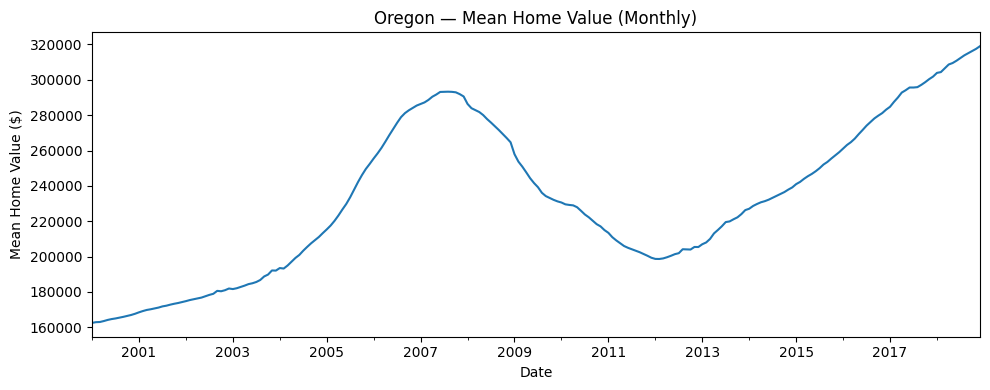

In [15]:
ts = (df_long
      .loc['2000-01-31':'2018-12-31', 'Home Value']
      .resample('ME')
      .mean())

print('Length:', len(ts), '| Range:', ts.index.min().date(), '->', ts.index.max().date())

ax = ts.plot(figsize=(10, 4), title='Oregon — Mean Home Value (Monthly)')
ax.set_ylabel('Mean Home Value ($)')
plt.tight_layout()
plt.show()

2) Check for and address null values

In [16]:
# Nulls at the zipcode level (before aggregation)
print('Nulls at zip level:', df_long['Home Value'].isna().sum(),
      'out of', len(df_long), 'rows')

# Nulls in the aggregated monthly-mean series
print('Nulls in the monthly mean ts:', ts.isna().sum())


ts = ts.interpolate(method='linear')
print('Nulls after interpolate:', ts.isna().sum())

Nulls at zip level: 17472 out of 100375 rows
Nulls in the monthly mean ts: 0
Nulls after interpolate: 0


3) Decompose the time series — is there seasonality?

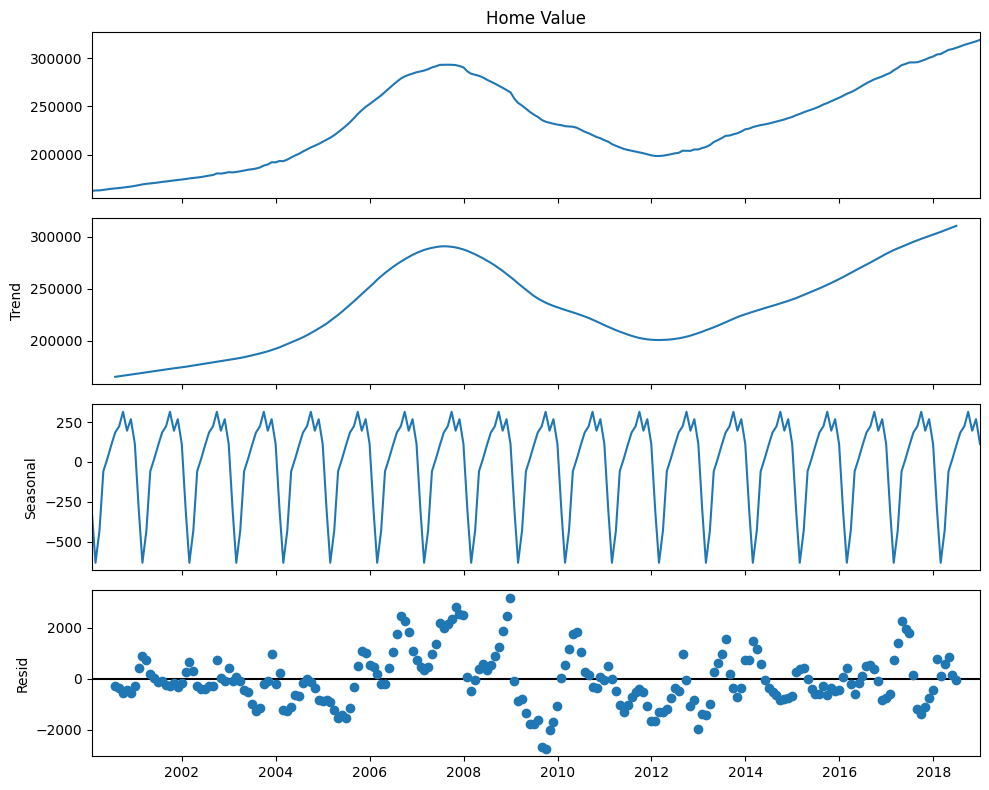

Seasonal amplitude: ~$948
Series mean level:  ~$232,995
Seasonal swing = 0.41% of the mean level


In [18]:
decomp = seasonal_decompose(ts)
fig = decomp.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

# Quantify how big the seasonal swing is relative to the level of the series
seasonal_amplitude = decomp.seasonal.max() - decomp.seasonal.min()
print(f'Seasonal amplitude: ~${seasonal_amplitude:,.0f}')
print(f'Series mean level:  ~${ts.mean():,.0f}')
print(f'Seasonal swing = {seasonal_amplitude / ts.mean() * 100:.2f}% of the mean level')

4) Is nonseasonal and/or seasonal differencing required?

In [19]:
def adf_test(series, name):
    result = adfuller(series.dropna())
    p = result[1]
    verdict = 'STATIONARY' if p < 0.05 else 'NOT stationary'
    print(f'{name:<28} ADF p-value = {p:.4f}  ->  {verdict}')

adf_test(ts, 'Raw series')
adf_test(ts.diff(), '1st difference (d=1)')
adf_test(ts.diff().diff(), '2nd difference (d=2)')
adf_test(ts.diff(12), 'Seasonal difference (D=1)')

Raw series                   ADF p-value = 0.3874  ->  NOT stationary
1st difference (d=1)         ADF p-value = 0.2559  ->  NOT stationary
2nd difference (d=2)         ADF p-value = 0.0000  ->  STATIONARY
Seasonal difference (D=1)    ADF p-value = 0.1406  ->  NOT stationary


In [20]:
from pmdarima.arima import ndiffs, nsdiffs

d_est = ndiffs(ts)
D_est = nsdiffs(ts, m=12)
print('Estimated nonseasonal differencing d =', d_est)
print('Estimated seasonal differencing    D =', D_est)

Estimated nonseasonal differencing d = 2
Estimated seasonal differencing    D = 0


5) ACF & PACF of the stationary (differenced) series — estimate initial orders

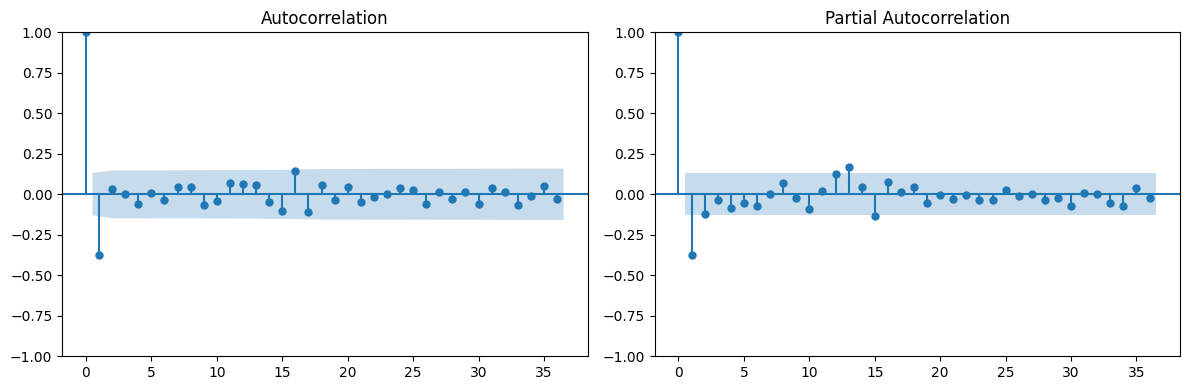

In [21]:
# Difference the series according to d_est / D_est found above
ts_stationary = ts.copy()
for _ in range(d_est):
    ts_stationary = ts_stationary.diff()
if D_est > 0:
    ts_stationary = ts_stationary.diff(12)
ts_stationary = ts_stationary.dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ts_stationary, lags=36, ax=axes[0])
plot_pacf(ts_stationary, lags=36, ax=axes[1], method='ywm')
plt.tight_layout()
plt.show()

6) Train / test split — hold out the **last 12 months** (2018) as test

Train: 216 months | Test: 12 months


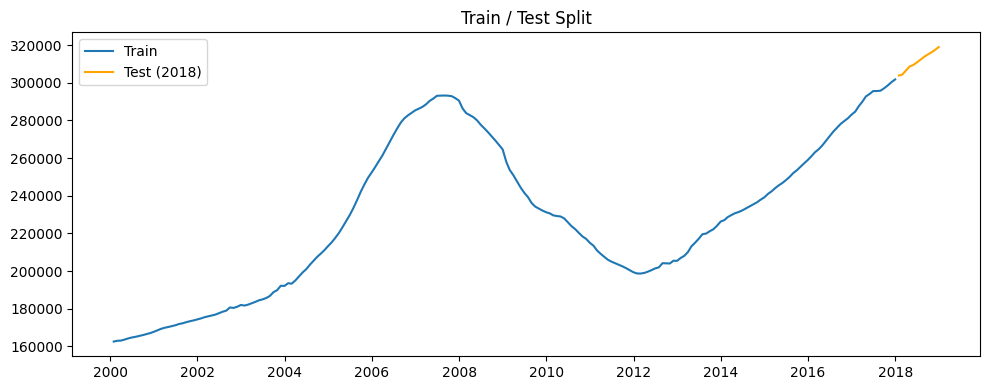

In [22]:
train = ts.loc[:'2017-12-31']
test = ts.loc['2018-01-31':]
print('Train:', len(train), 'months | Test:', len(test), 'months')

plt.figure(figsize=(10, 4))
plt.plot(train, label='Train')
plt.plot(test, label='Test (2018)', color='orange')
plt.legend()
plt.title('Train / Test Split')
plt.tight_layout()
plt.show()

7) Manual ARIMA/SARIMA — based on the exploration above

In [23]:
manual_order = (2, 2, 2)             # (p, d, q)
manual_seasonal_order = (0, 0, 0, 12)  # (P, D, Q, m) - seasonality was negligible

manual_model = SARIMAX(train,
                       order=manual_order,
                       seasonal_order=manual_seasonal_order)
manual_res = manual_model.fit()
manual_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             Home Value   No. Observations:                  216
Model:               SARIMAX(2, 2, 2)   Log Likelihood               -1725.611
Date:                Fri, 17 Jul 2026   AIC                           3461.222
Time:                        11:55:29   BIC                           3478.051
Sample:                    01-31-2000   HQIC                          3468.022
                         - 12-31-2017                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2194      8.017      0.027      0.978     -15.494      15.933
ar.L2          0.0746      4.854      0.015      0.988      -9.439       9.588
ma.L1         -0.2397      8.022     -0.030      0.976     -15.962      15.482
ma.L2         -0.0858      4.995     -0.017      0.986      -9.876       9.704
sigma2      5.217e+05   2.26e+04     23.075      0.000    4.77e+05    5.66e+05
===================================================================================
Ljung-Box (L1) (Q):                  26.41   Jarque-Bera (JB):               365.95
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.30   Skew:                            -1.16
Prob(H) (two-sided):                  0.27   Kurtosis:                         8.97
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

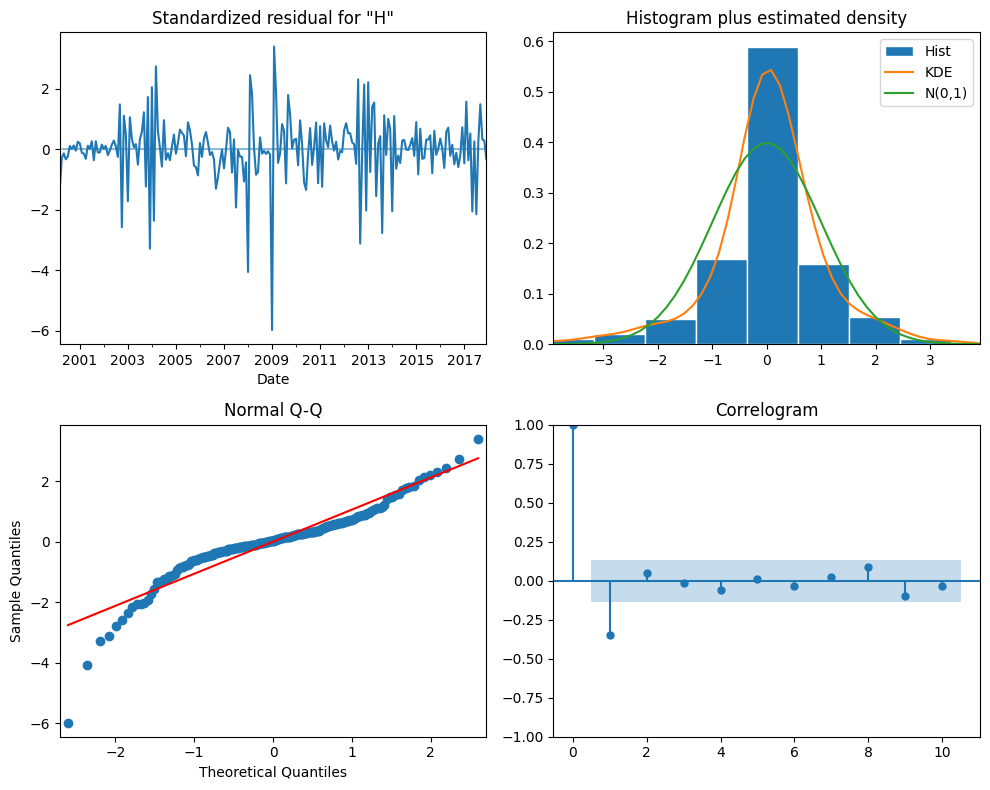

In [24]:
fig = manual_res.plot_diagnostics(figsize=(10, 8))
plt.tight_layout()
plt.show()

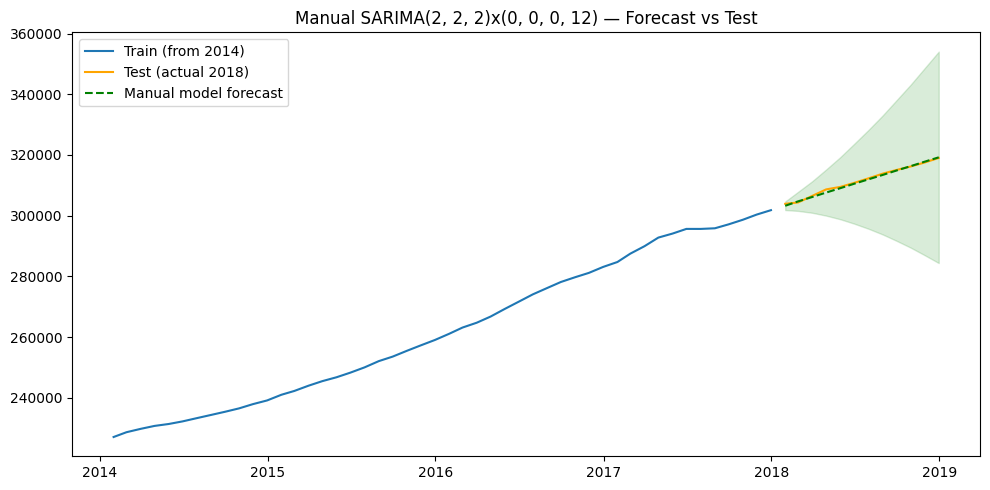

In [25]:
# Forecast the 12 test months
manual_fc = manual_res.get_forecast(steps=len(test))
manual_pred = manual_fc.predicted_mean
manual_ci = manual_fc.conf_int()

plt.figure(figsize=(10, 5))
plt.plot(train.loc['2014':], label='Train (from 2014)')
plt.plot(test, label='Test (actual 2018)', color='orange')
plt.plot(manual_pred, label='Manual model forecast', ls='--', color='green')
plt.fill_between(manual_ci.index, manual_ci.iloc[:, 0], manual_ci.iloc[:, 1],
                 color='green', alpha=0.15)
plt.legend()
plt.title(f'Manual SARIMA{manual_order}x{manual_seasonal_order} — Forecast vs Test')
plt.tight_layout()
plt.show()

In [26]:
def regression_metrics(y_true, y_pred, label=''):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f'--- {label} ---')
    print(f'MAE:  {mae:,.2f}')
    print(f'MSE:  {mse:,.2f}')
    print(f'RMSE: {rmse:,.2f}')
    print(f'R2:   {r2:.4f}')
    return {'Model': label, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

manual_metrics = regression_metrics(test, manual_pred, 'Manual SARIMA')

--- Manual SARIMA ---
MAE:  384.82
MSE:  204,860.50
RMSE: 452.62
R2:   0.9912


8) Tune with pmdarima's `auto_arima`

In [27]:
from pmdarima import auto_arima

auto = auto_arima(train,
                  seasonal=True, m=12,
                  d=None, D=None,          # let it estimate differencing itself
                  stepwise=True,
                  trace=True,
                  suppress_warnings=True,
                  error_action='ignore')

print('\nBest orders found:', auto.order, auto.seasonal_order)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=4016.508, Time=5.58 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=3822.254, Time=0.07 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=3823.629, Time=1.54 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3816.219, Time=0.73 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=3848.225, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=3817.779, Time=0.16 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=3818.217, Time=0.90 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=3817.994, Time=1.22 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=3816.230, Time=0.32 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=3819.930, Time=4.08 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=3820.431, Time=1.24 sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=3785.579, Time=7.51 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=3798.715, Time=3.77 sec
 ARIMA(1,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=7.95 sec
 ARIMA(1,1,1)(0,0,2)[12]

In [28]:
# Fit a model on the training data with the best parameters from auto_arima
auto_model = SARIMAX(train,
                     order=auto.order,
                     seasonal_order=auto.seasonal_order)
auto_res = auto_model.fit()
auto_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                         Home Value   No. Observations:                  216
Model:             SARIMAX(1, 1, 1)x(0, 0, 1, 12)   Log Likelihood               -1891.361
Date:                            Fri, 17 Jul 2026   AIC                           3790.722
Time:                                    11:58:13   BIC                           3804.205
Sample:                                01-31-2000   HQIC                          3796.170
                                     - 12-31-2017                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9203      0.028     32.324      0.000       0.864       0.976
ma.L1         -0.8850      0.032    -27.857      0.000      -0.947      -0.823
ma.S.L12       0.0027      0.026      0.104      0.917      -0.048       0.053
sigma2      2.816e+06    5.6e-10   5.03e+15      0.000    2.82e+06    2.82e+06
===================================================================================
Ljung-Box (L1) (Q):                 158.70   Jarque-Bera (JB):                36.06
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.54   Skew:                            -0.81
Prob(H) (two-sided):                  0.01   Kurtosis:                         4.19
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.75e+31. Standard errors may be unstable.
"""

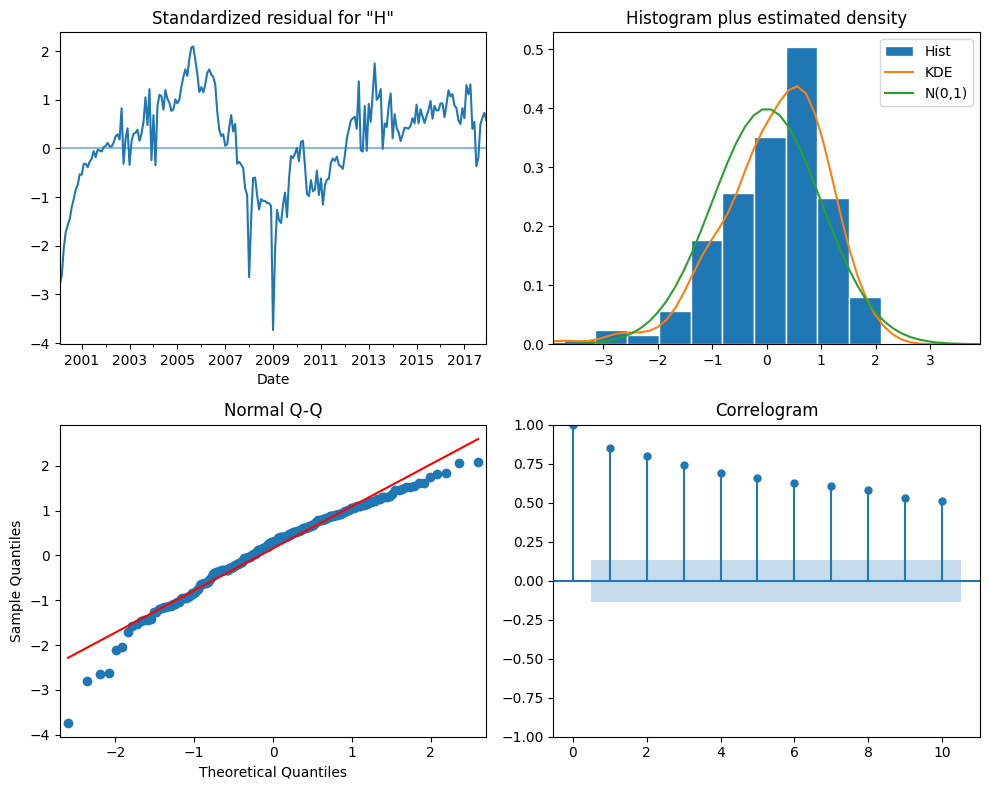

In [29]:
fig = auto_res.plot_diagnostics(figsize=(10, 8))
plt.tight_layout()
plt.show()

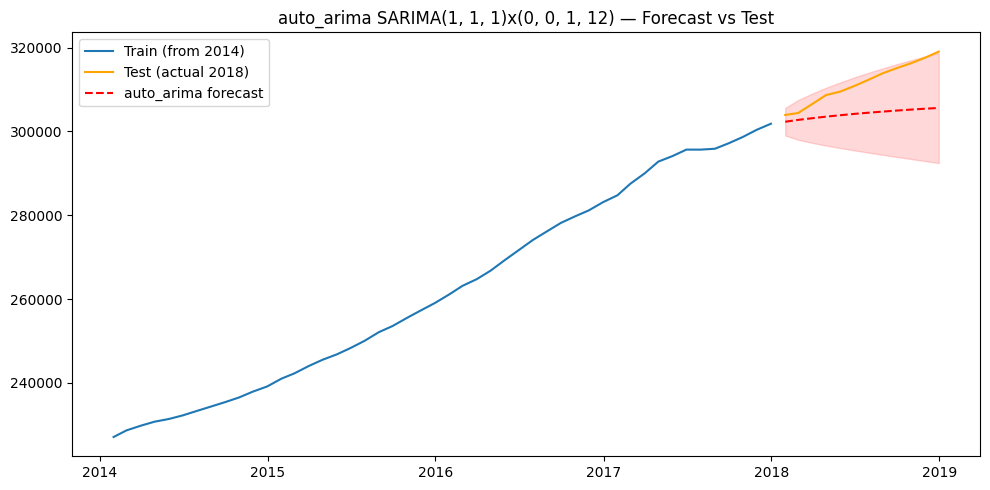

--- auto_arima SARIMA ---
MAE:  7,314.20
MSE:  67,975,679.90
RMSE: 8,244.74
R2:   -1.9195


In [30]:
auto_fc = auto_res.get_forecast(steps=len(test))
auto_pred = auto_fc.predicted_mean
auto_ci = auto_fc.conf_int()

plt.figure(figsize=(10, 5))
plt.plot(train.loc['2014':], label='Train (from 2014)')
plt.plot(test, label='Test (actual 2018)', color='orange')
plt.plot(auto_pred, label='auto_arima forecast', ls='--', color='red')
plt.fill_between(auto_ci.index, auto_ci.iloc[:, 0], auto_ci.iloc[:, 1],
                 color='red', alpha=0.15)
plt.legend()
plt.title(f'auto_arima SARIMA{auto.order}x{auto.seasonal_order} — Forecast vs Test')
plt.tight_layout()
plt.show()

auto_metrics = regression_metrics(test, auto_pred, 'auto_arima SARIMA')

9) Select the final model and justify the choice

In [31]:
comparison = pd.DataFrame([manual_metrics, auto_metrics]).set_index('Model')
comparison['AIC'] = [manual_res.aic, auto_res.aic]
comparison

,MAE,MSE,RMSE,R2,AIC
Model,,,,,
Manual SARIMA,384.821962,2.048605e+05,452.615177,0.991201,3461.221541
auto_arima SARIMA,7314.200479,6.797568e+07,8244.736497,-1.919490,3790.721999


10) True future forecast — refit the final model on the **entire** dataset and forecast the next 12 months (2019)

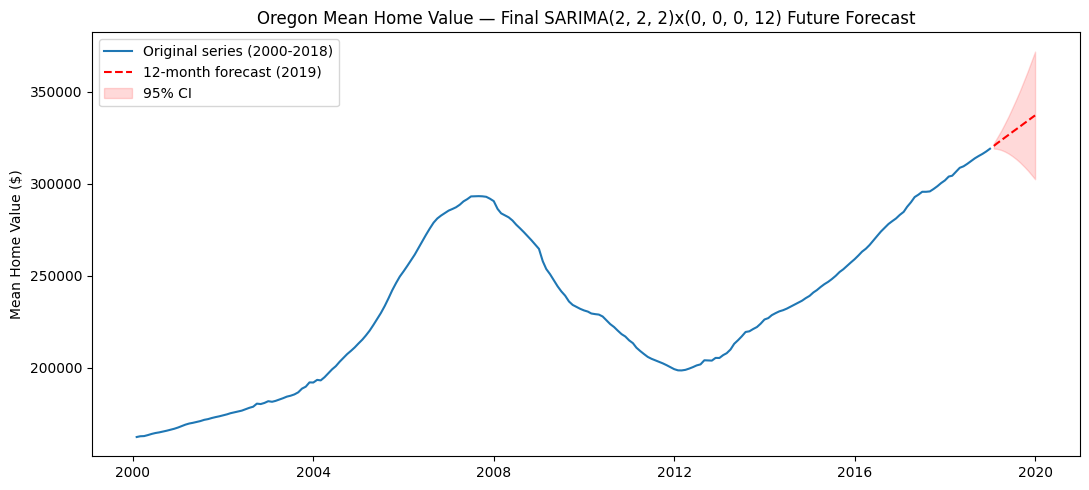

In [34]:
final_order = manual_order
final_seasonal_order = manual_seasonal_order

final_model = SARIMAX(ts, order=final_order, seasonal_order=final_seasonal_order)
final_res = final_model.fit()

future_fc = final_res.get_forecast(steps=12)
future_pred = future_fc.predicted_mean
future_ci = future_fc.conf_int()

plt.figure(figsize=(11, 5))
plt.plot(ts, label='Original series (2000-2018)')
plt.plot(future_pred, label='12-month forecast (2019)', ls='--', color='red')
plt.fill_between(future_ci.index, future_ci.iloc[:, 0], future_ci.iloc[:, 1],
                 color='red', alpha=0.15, label='95% CI')
plt.legend()
plt.title(f'Oregon Mean Home Value — Final SARIMA{final_order}x{final_seasonal_order} Future Forecast')
plt.ylabel('Mean Home Value ($)')
plt.tight_layout()
plt.show()

11) Forecast summary

In [36]:
last_observed = ts.iloc[-1]                 # Dec 2018 (last actual value)
final_month_value = future_pred.iloc[-1]    # Dec 2019 (last forecasted month)

pct_change_vs_last_actual = (final_month_value - last_observed) / last_observed * 100
pct_change_within_forecast = (future_pred.iloc[-1] - future_pred.iloc[0]) / future_pred.iloc[0] * 100

print(f'Last observed value (Dec 2018):            ${last_observed:,.0f}')
print(f'Predicted value in final forecast month:   ${final_month_value:,.0f}  ({future_pred.index[-1].date()})')
print(f'Percent change over the 12-month forecast: {pct_change_vs_last_actual:+.2f}% (vs last actual)')
print(f'Percent change first->last forecast month: {pct_change_within_forecast:+.2f}%')

Last observed value (Dec 2018):            $319,025
Predicted value in final forecast month:   $337,116  (2019-12-31)
Percent change over the 12-month forecast: +5.67% (vs last actual)
Percent change first->last forecast month: +5.17%


#Forecast Summary
Using the final SARIMA(2,2,2)(0,0,0,12) model fit on the entire dataset (2000–2018), the average home value in Oregon is forecast to reach 337,116 in December 2019 the final month of the 12 month forecast.
This represents an increase of +5.67% over the forecast horizon compared to the last observed value of 319,025 in December 2018. The forecast continues the strong upward trend that Oregon home prices have followed since the market bottomed out in 2012, with the model carrying forward the recent price momentum rather than assuming it flattens.